In [1]:
import os

raiz = 'Ojos'

# Datos de entrenamiento
train_dir = os.path.join(raiz, 'train')
train_dir_normal = os.path.join(train_dir, 'Normales')
train_dir_glaucoma = os.path.join(train_dir, 'Glaucomas')

# Datos de validación
val_dir = os.path.join(raiz, 'val')
val_dir_normal = os.path.join(val_dir, 'Normales')
val_dir_glaucoma = os.path.join(val_dir, 'Glaucomas')

# Datos de prueba
test_dir = os.path.join(raiz, 'test')
test_dir_normal = os.path.join(test_dir, 'Normales')
test_dir_glaucoma = os.path.join(test_dir, 'Glaucomas')

# Muestro la cantidad de imágenes en cada conjunto
suma_entrenamiento = len(os.listdir(train_dir_normal)) + len(os.listdir(train_dir_glaucoma))
suma_validacion = len(os.listdir(val_dir_normal)) + len(os.listdir(val_dir_glaucoma))
suma_prueba = len(os.listdir(test_dir_normal)) + len(os.listdir(test_dir_glaucoma))

print("Datos de entrenamiento:", suma_entrenamiento, "--- Normales:", len(os.listdir(train_dir_normal)), "--- Glaucoma:", len(os.listdir(train_dir_glaucoma)))
print("Datos de validación:", suma_validacion, "--- Normales:", len(os.listdir(val_dir_normal)), "--- Glaucoma:", len(os.listdir(val_dir_glaucoma)))
print("Datos de prueba:", suma_prueba, "--- Normales:", len(os.listdir(test_dir_normal)), "--- Glaucoma:", len(os.listdir(test_dir_glaucoma)))

Datos de entrenamiento: 339 --- Normales: 219 --- Glaucoma: 120
Datos de validación: 48 --- Normales: 31 --- Glaucoma: 17
Datos de prueba: 98 --- Normales: 63 --- Glaucoma: 35


In [2]:
# Realizo el data augmentation para mi conjunto de entrenamiento, validación y prueba
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_generator = ImageDataGenerator(preprocessing_function=preprocess_input,
                                     rotation_range=20,      # Rota la imagen hasta 20 grados
                                     width_shift_range=0.1,  # Mueve la imagen a los lados
                                     height_shift_range=0.1, # Mueve la imagen arriba/abajo
                                     zoom_range=0.2,         # Aplica un 20% de zoom aleatorio
                                     horizontal_flip=True    # Efecto espejo
)

val_generator = ImageDataGenerator(preprocessing_function=preprocess_input
)

test_generator = ImageDataGenerator(preprocessing_function=preprocess_input)

2026-02-21 16:19:29.918130: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-21 16:19:29.918430: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-21 16:19:29.961738: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 16:19:31.016724: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

In [3]:
train_generator = train_generator.flow_from_directory(train_dir,
                                    target_size=(224, 224),
                                    class_mode='categorical',
                                    classes=['Normales', 'Glaucomas'],
                                    batch_size=16)

val_generator = val_generator.flow_from_directory(val_dir,
                                  target_size=(224, 224),
                                  class_mode='categorical',
                                  classes=['Normales', 'Glaucomas'],
                                  batch_size=16)

test_generator = test_generator.flow_from_directory(test_dir,
                                   target_size=(224, 224),
                                   class_mode='categorical',
                                   classes=['Normales', 'Glaucomas'],
                                   batch_size=16)

Found 339 images belonging to 2 classes.
Found 48 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


In [4]:
# Obtención del modelo VGG16 preentrenado sin la parte de clasificación (sin las capas densas finales)
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layers in base_model.layers:
    layers.trainable = False

base_model.summary()

2026-02-21 16:19:31.489984: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras import Sequential

model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(1000, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │    62,721,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,002 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,980,986 (247.88 MB)

 Trainable params: 62,723,002 (239.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

model.compile(optimizer=Adam(learning_rate=1e-6),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

name_model = 'glaucomaMobileNetV2.h5'

checkpoint = ModelCheckpoint(name_model,
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = val_generator.samples // val_generator.batch_size

model.fit(train_generator,
          epochs=50,
          steps_per_epoch=steps_per_epoch,
          validation_data=val_generator,
          validation_steps=validation_steps,
          callbacks=[checkpoint])

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.5263 - loss: 1.2996
Epoch 1: val_accuracy improved from None to 0.60417, saving model to glaucomaMobileNetV2.h5



Epoch 1: finished saving model to glaucomaMobileNetV2.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 369ms/step - accuracy: 0.5480 - loss: 1.2253 - val_accuracy: 0.6042 - val_loss: 0.7462
Epoch 2/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.5625 - loss: 1.6771

/home/frannalpes/Escritorio/TFG/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.60417
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5625 - loss: 1.6771 - val_accuracy: 0.6042 - val_loss: 0.7441
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.6322 - loss: 1.1403
Epoch 3: val_accuracy did not improve from 0.60417
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.6316 - loss: 1.1010 - val_accuracy: 0.6042 - val_loss: 0.6594
Epoch 4/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.7500 - loss: 0.7658
Epoch 4: val_accuracy did not improve from 0.60417
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7500 - loss: 0.7658 - val_accuracy: 0.6042 - val_loss: 0.6587
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.5778 - loss: 1.2827
Epoch 5: val_accuracy improved from 0.60417 to 0.68750, saving model to glaucomaMobileNetV2.h5



Epoch 5: finished saving model to glaucomaMobileNetV2.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 305ms/step - accuracy: 0.6223 - loss: 1.1263 - val_accuracy: 0.6875 - val_loss: 0.6597
Epoch 6/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 288ms/step - accuracy: 0.6875 - loss: 1.0898
Epoch 6: val_accuracy did not improve from 0.68750
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6875 - loss: 1.0898 - val_accuracy: 0.6875 - val_loss: 0.6558
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.7048 - loss: 0.8207
Epoch 7: val_accuracy did not improve from 0.68750
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 270ms/step - accuracy: 0.6997 - loss: 0.8261 - val_accuracy: 0.6042 - val_loss: 0.6329
Epoch 8/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step - accuracy: 0.5625 - loss: 1.3199
Epoch 8: val_accuracy did not improve from 0.68750
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5625 - loss: 1.3199 - val_accuracy: 0.6042 - val_loss: 0.6327
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0


Epoch 9: finished saving model to glaucomaMobileNetV2.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 298ms/step - accuracy: 0.7028 - loss: 0.9091 - val_accuracy: 0.7083 - val_loss: 0.6586
Epoch 10/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step - accuracy: 0.6875 - loss: 1.5644
Epoch 10: val_accuracy did not improve from 0.70833
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6875 - loss: 1.5644 - val_accuracy: 0.7083 - val_loss: 0.6504
Epoch 11/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.6940 - loss: 0.8213
Epoch 11: val_accuracy did not improve from 0.70833
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - accuracy: 0.6347 - loss: 0.8963 - val_accuracy: 0.6458 - val_loss: 0.6231
Epoch 12/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 261ms/step - accuracy: 0.7500 - loss: 0.5828
Epoch 12: val_accuracy did not improve from 0.70833
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7500 - loss: 0.5828 - val_accuracy: 0.6667 - val_loss: 0.6239
Epoch 13/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accu


Epoch 25: finished saving model to glaucomaMobileNetV2.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step - accuracy: 0.7678 - loss: 0.6393 - val_accuracy: 0.7708 - val_loss: 0.5745
Epoch 26/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 281ms/step - accuracy: 0.6875 - loss: 0.6552
Epoch 26: val_accuracy did not improve from 0.77083
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6875 - loss: 0.6552 - val_accuracy: 0.7500 - val_loss: 0.5728
Epoch 27/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8239 - loss: 0.4885
Epoch 27: val_accuracy did not improve from 0.77083
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.7827 - loss: 0.6188 - val_accuracy: 0.7500 - val_loss: 0.5686
Epoch 28/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.6667 - loss: 1.5526
Epoch 28: val_accuracy did not improve from 0.77083
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6667 - loss: 1.5526 - val_accuracy: 0.7500 - val_loss: 0.5694
Epoch 29/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - acc


Epoch 41: finished saving model to glaucomaMobileNetV2.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step - accuracy: 0.7957 - loss: 0.5811 - val_accuracy: 0.7917 - val_loss: 0.5180
Epoch 42/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step - accuracy: 0.7500 - loss: 1.0249
Epoch 42: val_accuracy did not improve from 0.79167
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7500 - loss: 1.0249 - val_accuracy: 0.7917 - val_loss: 0.5174
Epoch 43/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7817 - loss: 0.4661
Epoch 43: val_accuracy did not improve from 0.79167
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.7926 - loss: 0.5105 - val_accuracy: 0.7708 - val_loss: 0.5386
Epoch 44/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 272ms/step - accuracy: 0.6875 - loss: 0.4166
Epoch 44: val_accuracy did not improve from 0.79167
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6875 - loss: 0.4166 - val_accuracy: 0.7708 - val_loss: 0.5388
Epoch 45/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - acc

In [7]:
model.load_weights(name_model)

test_loss, test_acc = model.evaluate(test_generator)
print("test_acc:", test_acc)
print("test_loss:", test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.8367 - loss: 0.3722
test_acc: 0.8367347121238708
test_loss: 0.37224018573760986


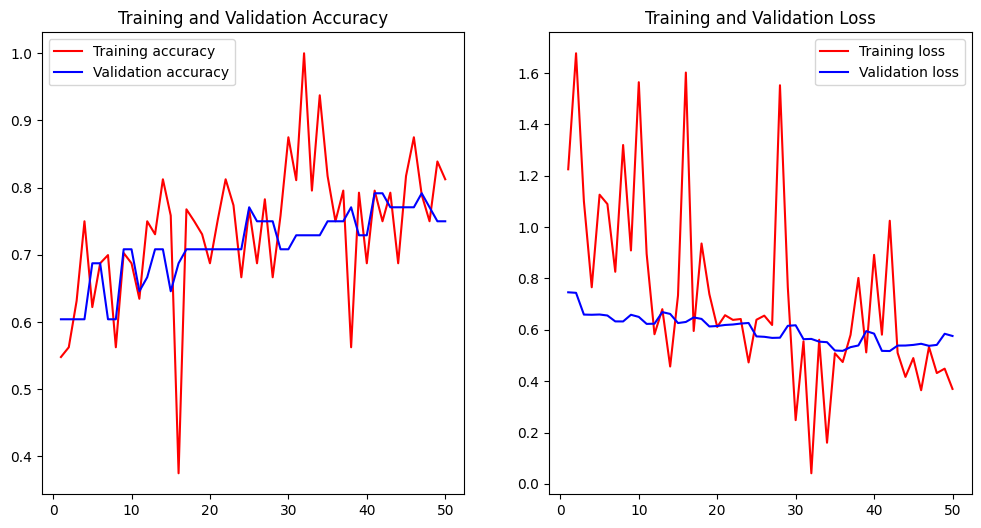

In [8]:
# Pinto las curvas de entrenamiento y validación

# Muestro las gráficas de entrenamiento
import matplotlib.pyplot as plt

# Gráficos de entrenamiento
acc = model.history.history['accuracy']
val_acc = model.history.history['val_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [9]:
from tensorflow.keras.optimizers import Adam

model.load_weights('glaucomaMobileNetV2.h5')

model.trainable = True # Descongelo todas las capas para el deep-tuning

name_deep = 'glaucomaMobileNetV2_deep.h5'

checkpointDeep = ModelCheckpoint(name_deep,
                                 monitor='val_accuracy',
                                 save_best_only=True,
                                 mode='max',
                                 verbose=1)

model.compile(optimizer=Adam(learning_rate=1e-6),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_generator,
          epochs=50,
          validation_data=val_generator,
          steps_per_epoch=steps_per_epoch,
          callbacks=[checkpointDeep])

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8024 - loss: 0.4793
Epoch 1: val_accuracy improved from None to 0.75000, saving model to glaucomaMobileNetV2_deep.h5



Epoch 1: finished saving model to glaucomaMobileNetV2_deep.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 348ms/step - accuracy: 0.8204 - loss: 0.4632 - val_accuracy: 0.7500 - val_loss: 0.5188
Epoch 2/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.8125 - loss: 0.2867
Epoch 2: val_accuracy improved from 0.75000 to 0.77083, saving model to glaucomaMobileNetV2_deep.h5



Epoch 2: finished saving model to glaucomaMobileNetV2_deep.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8125 - loss: 0.2867 - val_accuracy: 0.7708 - val_loss: 0.5213
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.8154 - loss: 0.4921
Epoch 3: val_accuracy did not improve from 0.77083
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 273ms/step - accuracy: 0.8142 - loss: 0.5098 - val_accuracy: 0.7500 - val_loss: 0.5366
Epoch 4/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 269ms/step - accuracy: 0.8750 - loss: 0.2221
Epoch 4: val_accuracy did not improve from 0.77083
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8750 - loss: 0.2221 - val_accuracy: 0.7708 - val_loss: 0.5389
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7772 - loss: 0.6011
Epoch 5: val_accuracy improved from 0.77083 to 0.79167, saving model to glaucomaMobileNetV2_deep.h5



Epoch 5: finished saving model to glaucomaMobileNetV2_deep.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 314ms/step - accuracy: 0.8155 - loss: 0.5109 - val_accuracy: 0.7917 - val_loss: 0.5423
Epoch 6/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 1.0000 - loss: 0.0060
Epoch 6: val_accuracy did not improve from 0.79167
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.7917 - val_loss: 0.5383
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.8149 - loss: 0.4472
Epoch 7: val_accuracy did not improve from 0.79167
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step - accuracy: 0.8111 - loss: 0.4765 - val_accuracy: 0.7917 - val_loss: 0.5246
Epoch 8/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step - accuracy: 0.8125 - loss: 0.3798
Epoch 8: val_accuracy improved from 0.79167 to 0.81250, saving model to glaucomaMobileNetV2_deep.h5



Epoch 8: finished saving model to glaucomaMobileNetV2_deep.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8125 - loss: 0.3798 - val_accuracy: 0.8125 - val_loss: 0.5208
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.8059 - loss: 0.4845
Epoch 9: val_accuracy did not improve from 0.81250
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.7864 - loss: 0.4965 - val_accuracy: 0.7917 - val_loss: 0.5342
Epoch 10/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 254ms/step - accuracy: 0.8125 - loss: 0.4709
Epoch 10: val_accuracy did not improve from 0.81250
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8125 - loss: 0.4709 - val_accuracy: 0.7917 - val_loss: 0.5380
Epoch 11/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.7818 - loss: 0.4854
Epoch 11: val_accuracy did not improve from 0.81250
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - accuracy: 0.7771 - loss: 0.4935 - val_accuracy: 0.8125 - val_loss: 0.5237
Epoch 12/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step - a


Epoch 35: finished saving model to glaucomaMobileNetV2_deep.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 303ms/step - accuracy: 0.8452 - loss: 0.4363 - val_accuracy: 0.8333 - val_loss: 0.4788
Epoch 36/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 285ms/step - accuracy: 0.8750 - loss: 0.4202
Epoch 36: val_accuracy improved from 0.83333 to 0.85417, saving model to glaucomaMobileNetV2_deep.h5



Epoch 36: finished saving model to glaucomaMobileNetV2_deep.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8750 - loss: 0.4202 - val_accuracy: 0.8542 - val_loss: 0.4781
Epoch 37/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.8642 - loss: 0.3369
Epoch 37: val_accuracy did not improve from 0.85417
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 270ms/step - accuracy: 0.8607 - loss: 0.3301 - val_accuracy: 0.8542 - val_loss: 0.4693
Epoch 38/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 267ms/step - accuracy: 0.8750 - loss: 0.4150
Epoch 38: val_accuracy did not improve from 0.85417
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8750 - loss: 0.4150 - val_accuracy: 0.8542 - val_loss: 0.4693
Epoch 39/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8386 - loss: 0.3721
Epoch 39: val_accuracy did not improve from 0.85417
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 265ms/step - accuracy: 0.8421 - loss: 0.3848 - val_accuracy: 0.7500 - val_loss: 0.5302
Epoch 40/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 269ms/step 

In [10]:
model.load_weights(name_deep)

test_loss, test_acc = model.evaluate(test_generator)
print("test_acc:", test_acc)
print("test_loss:", test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.8673 - loss: 0.3470
test_acc: 0.8673469424247742
test_loss: 0.3469538688659668


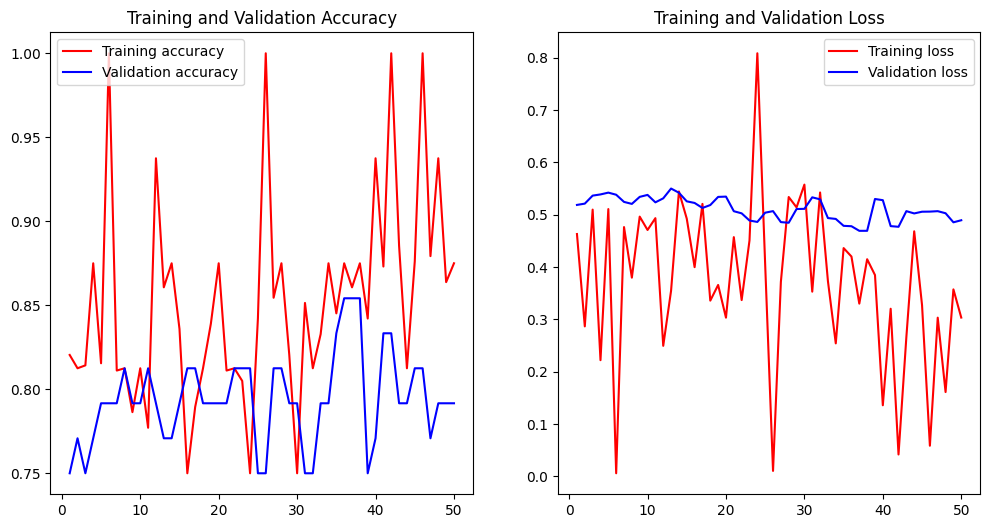

In [11]:
# Gráficos de entrenamiento
acc = model.history.history['accuracy']
val_acc = model.history.history['val_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()